In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [87]:
df=pd.read_csv('/content/Mall_Customers_Enhanced (1).csv')
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
0,1,Male,19,15,39,18-25,11.10,456,3,Budget
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury
2,3,Female,20,16,6,18-25,15.36,594,2,Budget
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury
4,5,Female,31,17,40,26-35,12.47,480,5,Budget


In [88]:
df.shape

(200, 10)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
 5   Age Group               196 non-null    object 
 6   Estimated Savings (k$)  200 non-null    float64
 7   Credit Score            200 non-null    int64  
 8   Loyalty Years           200 non-null    int64  
 9   Preferred Category      200 non-null    object 
dtypes: float64(1), int64(6), object(3)
memory usage: 15.8+ KB


In [90]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Age Group,4
Estimated Savings (k$),0
Credit Score,0
Loyalty Years,0
Preferred Category,0


In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Estimated Savings (k$),Credit Score,Loyalty Years
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,40.247950,743.680000,5.930000
std,57.879185,13.969007,26.264721,25.823522,21.333448,155.176727,1.570808
min,1.000000,18.000000,15.000000,1.000000,6.460000,300.000000,2.000000
25%,50.750000,28.750000,41.500000,34.750000,28.800000,697.000000,5.000000
50%,100.500000,36.000000,61.500000,50.000000,36.410000,833.000000,6.000000
75%,150.250000,49.000000,78.000000,73.000000,44.967500,850.000000,7.000000
max,200.000000,70.000000,137.000000,99.000000,120.560000,850.000000,9.000000


# EDA

In [93]:
df1.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Age Group', 'Estimated Savings (k$)', 'Credit Score', 'Loyalty Years',
       'Preferred Category'],
      dtype='object')

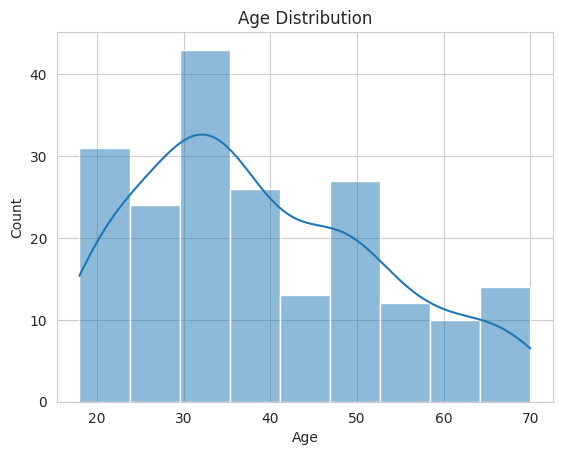

In [94]:
sns.set_style("whitegrid")

#Age distribution
plt.figure()
sns.histplot(df1['Age'], kde=True)
plt.title("Age Distribution")
plt.show()



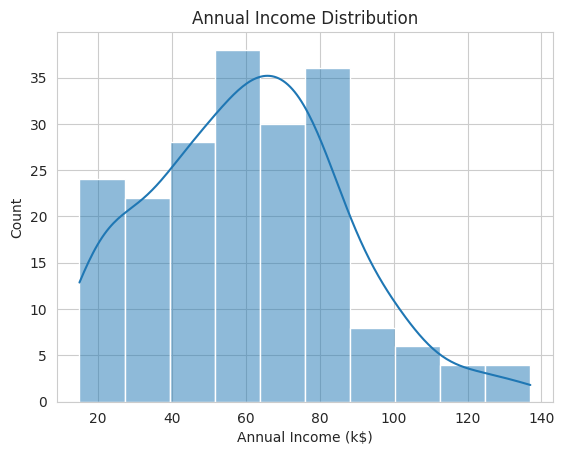

In [95]:
#Annual Income
plt.figure()
sns.histplot(df1['Annual Income (k$)'], kde=True)
plt.title("Annual Income Distribution")
plt.show()



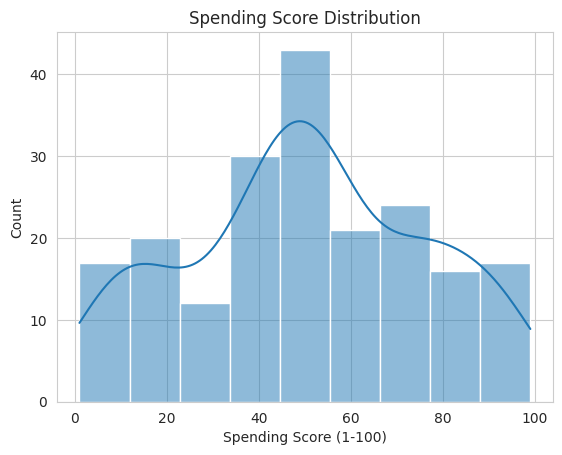

In [96]:
#Spending Score
plt.figure()
sns.histplot(df1['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()



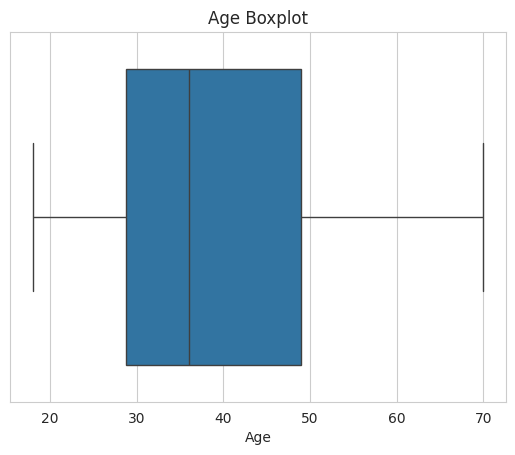

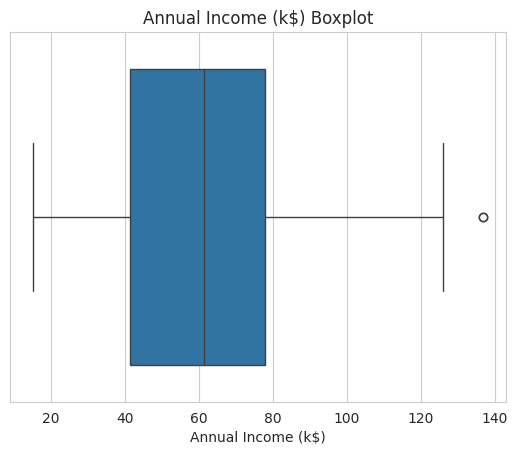

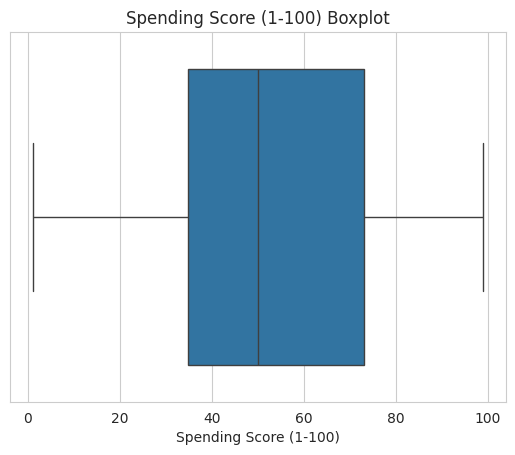

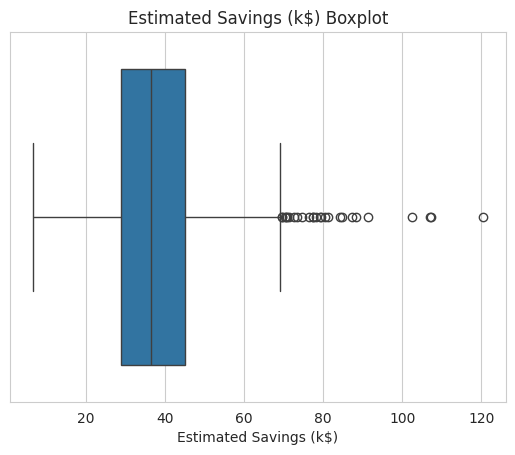

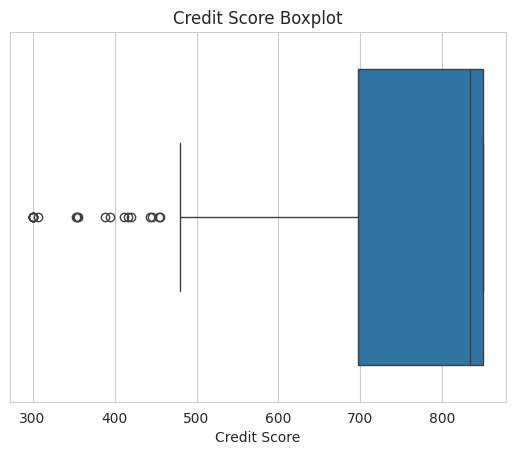

In [97]:
#Boxplot(Outliers detection)
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
        'Estimated Savings (k$)', 'Credit Score']

for col in cols:
    plt.figure()
    sns.boxplot(x=df1[col])
    plt.title(f"{col} Boxplot")
    plt.show()

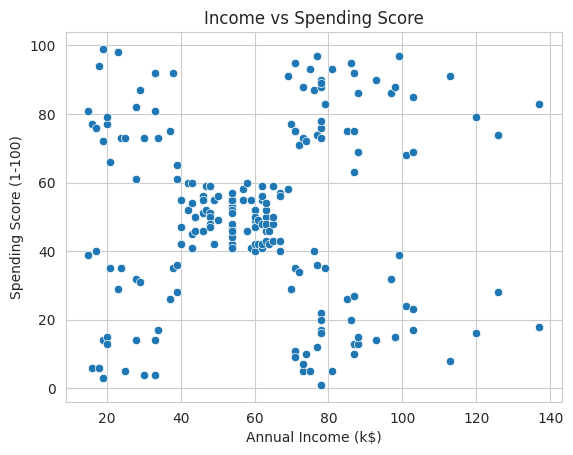

In [98]:
#Income vs Spending
plt.figure()
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df1)
plt.title("Income vs Spending Score")
plt.show()

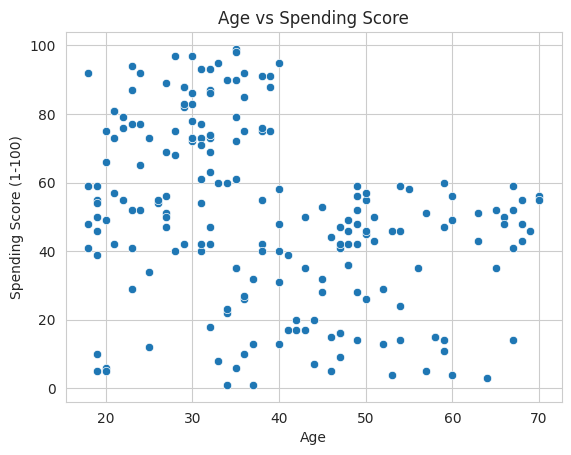

In [99]:
#Age VS Spending
plt.figure()
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df1)
plt.title("Age vs Spending Score")
plt.show()

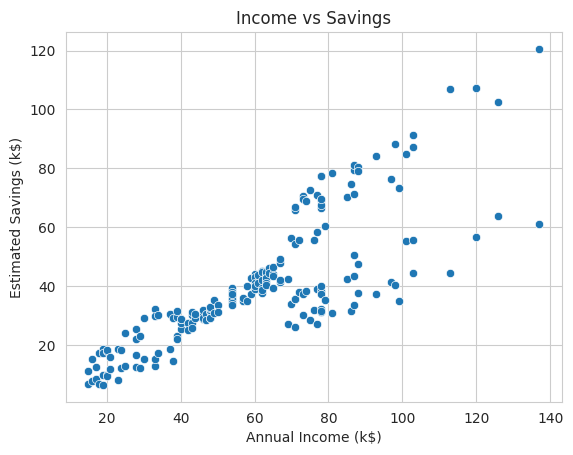

In [100]:
#Income VS Saving
plt.figure()
sns.scatterplot(x='Annual Income (k$)', y='Estimated Savings (k$)', data=df1)
plt.title("Income vs Savings")
plt.show()

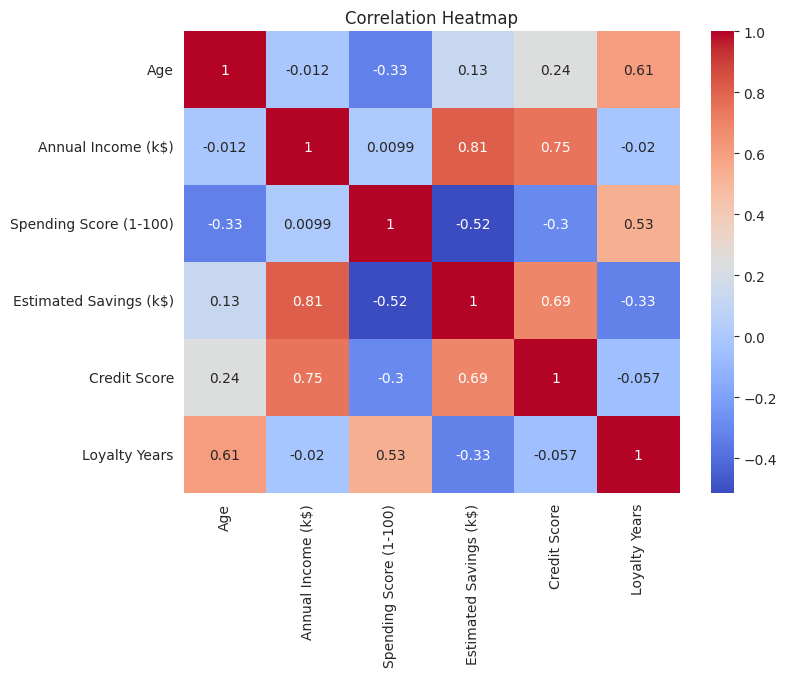

In [101]:
#Correlation Analysis
plt.figure(figsize=(8,6))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

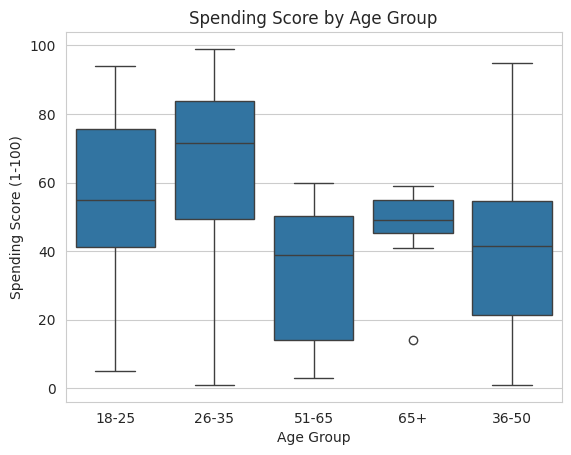

In [104]:
#AgeGroup Vs Spending
plt.figure()
sns.boxplot(x='Age Group', y='Spending Score (1-100)', data=df1)
plt.title("Spending Score by Age Group")
plt.show()

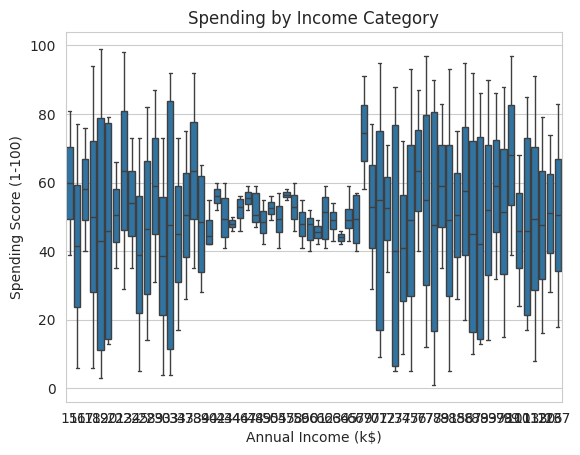

In [107]:
#Income_Category VS Spending
plt.figure()
sns.boxplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df1)
plt.title("Spending by Income Category")
plt.show()

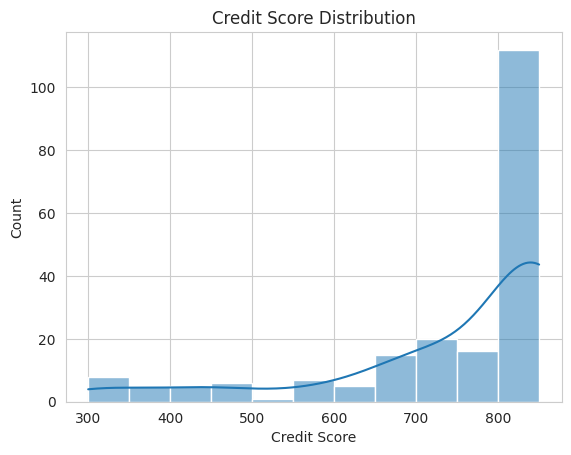

In [108]:
#Distribution of Credit Score
plt.figure()
sns.histplot(df1['Credit Score'], kde=True)
plt.title("Credit Score Distribution")
plt.show()


## Clustering Elbow Method

In [109]:
X = df1[['Annual Income (k$)', 'Spending Score (1-100)']]

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

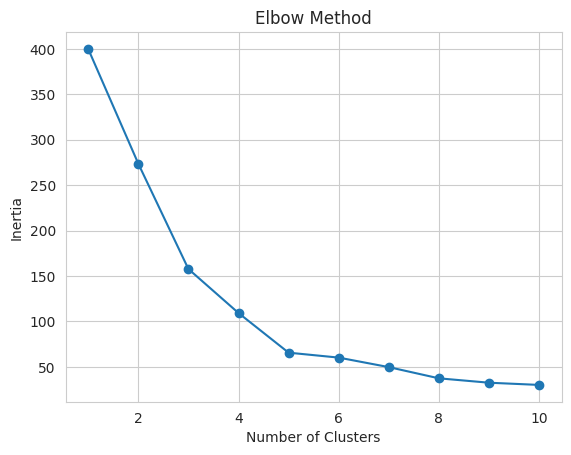

In [111]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [112]:
kmeans = KMeans(n_clusters=5, random_state=42)
df1['Cluster'] = kmeans.fit_predict(X_scaled)

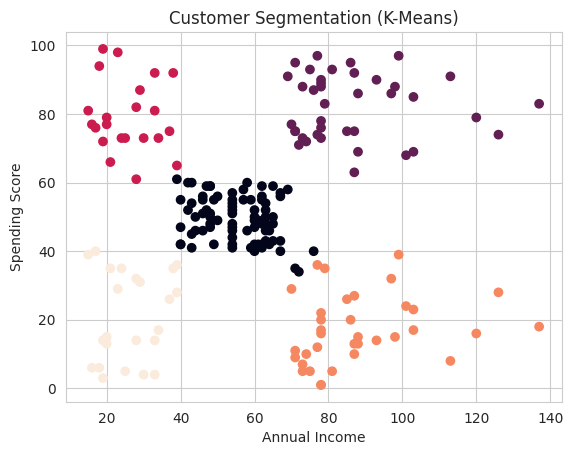

In [113]:
plt.figure()
plt.scatter(df1['Annual Income (k$)'],
            df1['Spending Score (1-100)'],
            c=df1['Cluster'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (K-Means)")
plt.show()

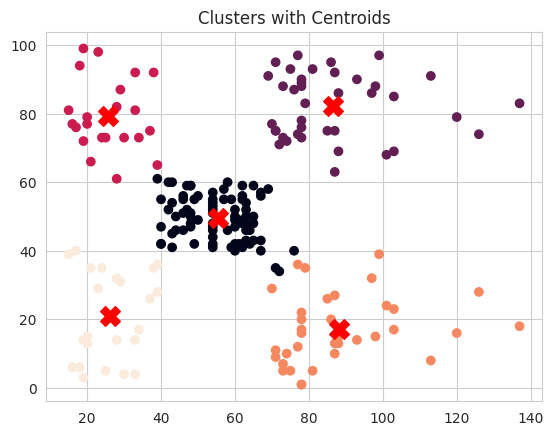

In [114]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure()
plt.scatter(df1['Annual Income (k$)'],
            df1['Spending Score (1-100)'],
            c=df1['Cluster'])

plt.scatter(centers[:,0], centers[:,1],
            s=200, c='red', marker='X')

plt.title("Clusters with Centroids")
plt.show()

In [115]:
df1['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


## Silhouette Score

In [116]:
from sklearn.metrics import silhouette_score
sil_scores = []

K = range(2, 11)  # Silhouette doesn't work for k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

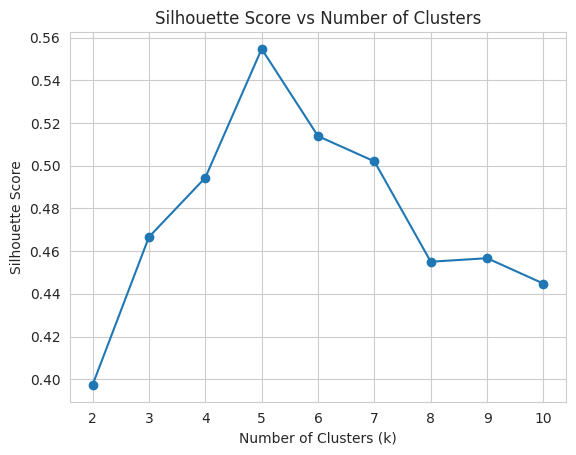

In [117]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [118]:
best_k = K[sil_scores.index(max(sil_scores))]
print("Best K:", best_k)

Best K: 5


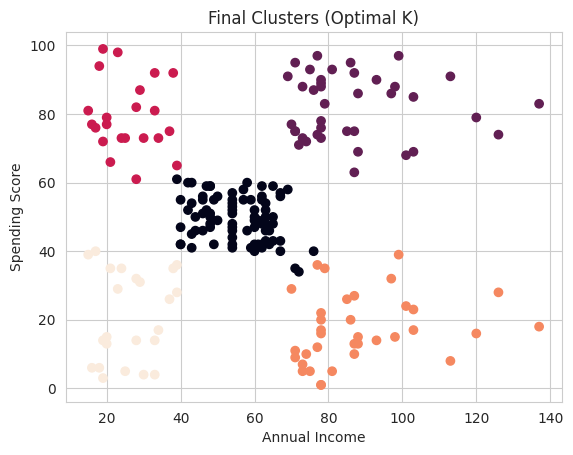

In [119]:
plt.figure()
plt.scatter(df1['Annual Income (k$)'],
            df1['Spending Score (1-100)'],
            c=df1['Cluster'])

plt.title("Final Clusters (Optimal K)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [120]:
df1.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [121]:
cluster_names = {
    0: 'Budget Customers',
    1: 'Premium Customers',
    2: 'Conservative Customers',
    3: 'Impulsive Customers',
    4: 'Average Customers'
}

df1['Customer Segment'] = df1['Cluster'].map(cluster_names)

In [122]:
df1[['Cluster', 'Customer Segment']].head()

,Cluster,Customer Segment
0,4,Average Customers
1,2,Conservative Customers
2,4,Average Customers
3,2,Conservative Customers
4,4,Average Customers


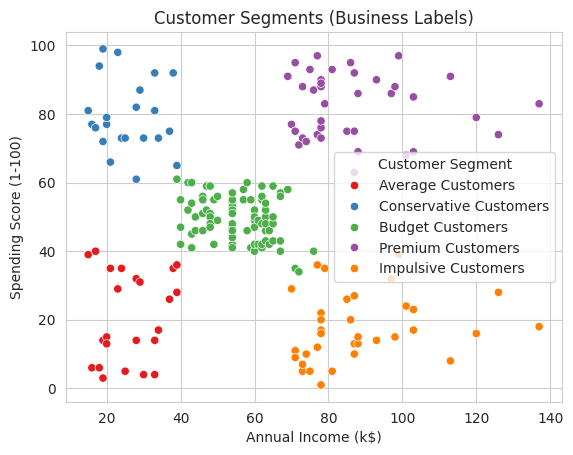

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Customer Segment',
    data=df1,
    palette='Set1'
)

plt.title("Customer Segments (Business Labels)")
plt.show()

In [125]:
print(df1['Customer Segment'].value_counts())

Customer Segment
Budget Customers          81
Premium Customers         39
Impulsive Customers       35
Average Customers         23
Conservative Customers    22
Name: count, dtype: int64


In [126]:
df1

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category,Cluster,Customer Segment
0,Male,19,15,39,18-25,11.10,456,3,Budget,4,Average Customers
1,Male,21,15,81,18-25,6.90,300,6,Luxury,2,Conservative Customers
2,Female,20,16,6,18-25,15.36,594,2,Budget,4,Average Customers
3,Female,23,16,77,18-25,7.79,300,6,Luxury,2,Conservative Customers
4,Female,31,17,40,26-35,12.47,480,5,Budget,4,Average Customers
...,...,...,...,...,...,...,...,...,...,...,...
195,Female,35,120,79,26-35,56.80,850,7,Luxury,1,Premium Customers
196,Female,45,126,28,36-50,102.48,850,5,Electronics,3,Impulsive Customers
197,Male,32,126,74,26-35,63.84,850,6,Luxury,1,Premium Customers
198,Male,32,137,18,26-35,120.56,850,4,Fashion,3,Impulsive Customers


In [127]:
df1.to_csv('customer_data.csv', index=False)

##Customers were segmented using K-Means clustering.
##Clusters were interpreted based on income and spending behavior.
##Business labels were assigned to improve interpretability.
##Key segments identified:

###1)Premium Customers: High income & high spending
###2)Budget Customers: Low income & low spending
###3)Conservative Customers: High income & low spending
###4)Impulsive Customers: Low income & high spending
###5)Average Customers: Moderate income & spending